# High Noon 🏔️
### Is buying at an all-time high really the riskiest moment?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ATH a sell signal?: Busted](https://img.shields.io/badge/ATH_a_sell_signal%3F-Busted-8b949e?style=flat-square)

Every time an index prints a record, someone says *"don't buy the high — wait for a pullback."* We take the rule literally: we look at every day SPY sat within 1% of its all-time high and ask what happened *next* — over the following month, quarter and year — versus the days it was **not** near a high. The answer is the opposite of the folklore.

> 📓 **This is the plain-language layer.** The HAC *t*-stats, the Wilson intervals and the backtest are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (high_noon/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from high_noon import data, strategy

AS_OF = "2026-06-12"
NEAR_PCT = 0.01
M = strategy.MONTH
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
flag = strategy.at_ath(close, NEAR_PCT)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(f"days within 1% of the running all-time high: {flag.mean()*100:.1f}%")


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=b8f3c9d7d95e
days within 1% of the running all-time high: 29.0%


## The answer first 🎯

| Question | Answer |
|---|---|
| Are returns *worse* after an all-time high? | **No** — over the next year the high day actually does a touch *better* (**+1.4 points** on average). |
| Is a record a 'sell signal'? | **No** — a year out, **84.6%** of at-high days were higher vs **80.5%** of off-high days. |
| Does *waiting for a pullback* pay? | **No** — sitting out the highs earns **1.7 points/yr less** and leaves you with **0.6x** the money, with no less drawdown. |

## 1 · The claim

*"Never buy at an all-time high — it's the riskiest moment, a classic sell signal. Wait for a pullback."* The instinct is that a record means 'expensive', 'overbought', 'due to fall' — so buying there is buying the top.

## 2 · So what?

If it were true, the discipline would be obvious: never add at a record, always wait for a dip. Whole investing habits are built on this fear. So it's worth checking whether the data agrees — or whether a generation of investors talked themselves out of the best days.

## 3 · How would we even know?

We flag every day SPY closed within **1%** of its running all-time high, then measure the **forward 1-, 3- and 12-month return** of those days and compare them to the days that were *not* near a high. If the folklore is right, the at-high days should show clearly **worse** forward returns. If they don't, the rule is busted.

## 4 · The teardown — what actually happens after a record

First, the average forward return, at-high vs off-high, at each horizon.

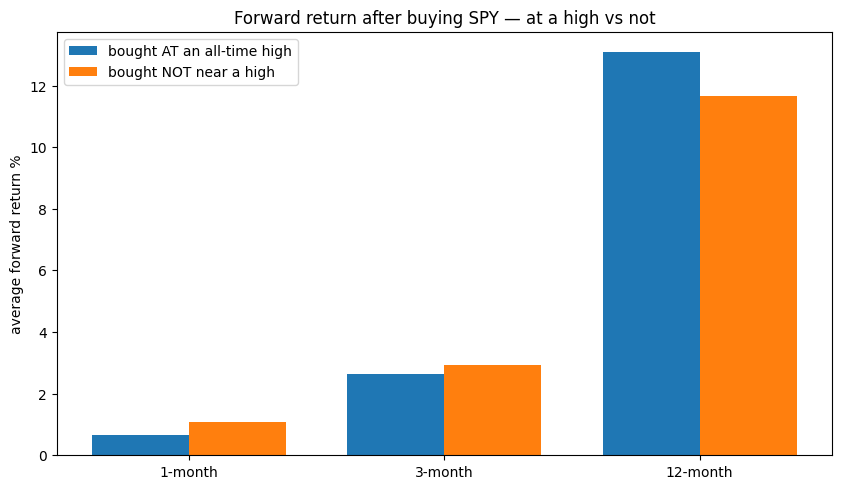

  1-month:  at-high  +0.67%   off-high  +1.09%   diff -0.42 pts
  3-month:  at-high  +2.63%   off-high  +2.94%   diff -0.31 pts
 12-month:  at-high +13.09%   off-high +11.65%   diff +1.44 pts


In [2]:
rows = []
for h, lab in [(M, '1-month'), (3*M, '3-month'), (12*M, '12-month')]:
    s = strategy.conditional_forward_stats(close, h, NEAR_PCT)
    rows.append((lab, s['at']['mean']*100, s['not_at']['mean']*100))
labs = [r[0] for r in rows]; xs = np.arange(len(labs)); w=0.38
plt.bar(xs-w/2, [r[1] for r in rows], w, label='bought AT an all-time high')
plt.bar(xs+w/2, [r[2] for r in rows], w, label='bought NOT near a high')
plt.xticks(xs, labs); plt.ylabel('average forward return %'); plt.legend()
plt.title('Forward return after buying SPY — at a high vs not'); plt.show()
for lab, a, n in rows: print(f'{lab:>9}:  at-high {a:+6.2f}%   off-high {n:+6.2f}%   diff {a-n:+5.2f} pts')

The bars are basically the same height — and at **12 months** the all-time-high bar is *taller*. Buying the record did not hurt you; over a year it helped a little. Highs happen in uptrends, and uptrends tend to continue.

Now the **win-rate** — how often were you simply *up* a year later?

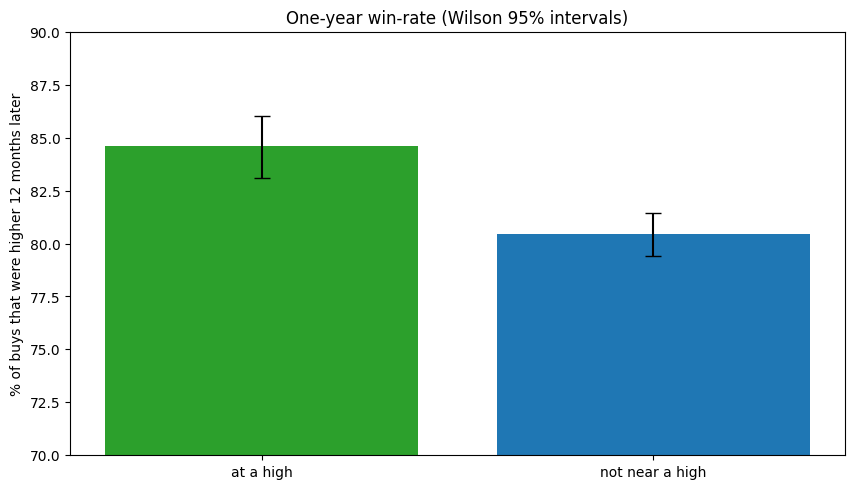

at a high:  84.6%  [83.1, 86.0]
off a high: 80.5%  [79.4, 81.5]


In [3]:
s12 = strategy.conditional_forward_stats(close, 12*M, NEAR_PCT)
at, no = s12['at'], s12['not_at']
plt.bar(['at a high','not near a high'], [at['win_rate']*100, no['win_rate']*100],
        yerr=[[(at['win_rate']-at['win_lo'])*100,(no['win_rate']-no['win_lo'])*100],
              [(at['win_hi']-at['win_rate'])*100,(no['win_hi']-no['win_rate'])*100]],
        capsize=6, color=['C2','C0'])
plt.ylabel('% of buys that were higher 12 months later'); plt.ylim(70, 90)
plt.title('One-year win-rate (Wilson 95% intervals)'); plt.show()
print(f"at a high:  {at['win_rate']*100:.1f}%  [{at['win_lo']*100:.1f}, {at['win_hi']*100:.1f}]")
print(f"off a high: {no['win_rate']*100:.1f}%  [{no['win_lo']*100:.1f}, {no['win_hi']*100:.1f}]")

Buying at an all-time high was higher a year later **84.6%** of the time — *better* than the **80.5%** for off-high buys, and the error bars don't overlap. The 'risky moment' was, if anything, the slightly *safer* one.

Finally, the rule as a **strategy**: sit in cash whenever you're near a high. Did 'waiting for the pullback' pay?

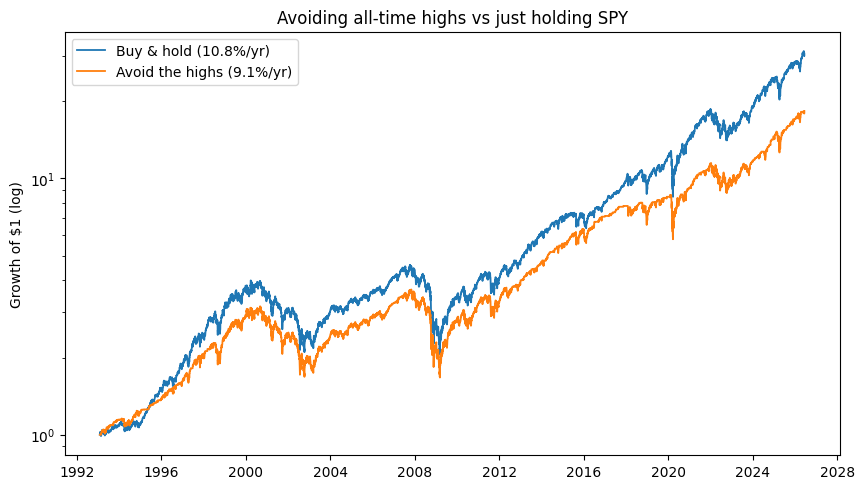

avoid-highs ends at 0.60x buy-and-hold


In [4]:
pos = strategy.avoid_highs_position(close, NEAR_PCT, lag=1)
timer = strategy.backtest(close, pos, cost_bps=5.0)
bh = strategy.buy_and_hold(close)
plt.plot(bh['equity'], label=f"Buy & hold ({bh['cagr']*100:.1f}%/yr)", lw=1.3)
plt.plot(timer['equity'], label=f"Avoid the highs ({timer['cagr']*100:.1f}%/yr)", lw=1.3)
plt.yscale('log'); plt.ylabel('Growth of $1 (log)'); plt.legend()
plt.title('Avoiding all-time highs vs just holding SPY'); plt.show()
print(f"avoid-highs ends at {timer['final']/bh['final']:.2f}x buy-and-hold")

The avoid-the-highs line ends **below** buy-and-hold — **0.6x** the wealth — because every time you sat out a record you sat out the trend that followed. You paid **1.7 points a year** for the privilege, and got *no* less drawdown for it.

## 5 · The verdict

- **Is an ATH a sell signal? → Busted.** Forward returns are as good (and a year out, *better*) after a record; the one-year win-rate is **84.6%** vs **80.5%**.
- **Signal → None.** The at-minus-off difference never clears the noise bar at any horizon.
- **Waiting for the pullback? → Mirage.** It costs **1.7 pts/yr** and leaves you with **0.6x** the money, for no risk reduction.

## 6 · Could you actually trade it?

You *can* run 'avoid the highs' — it's just SPY — but it's a losing trade: it underperforms buy-and-hold while sitting in cash 29% of the time, with the same drawdown. The thing it asks you to dodge (records) is exactly where the trend lives. There's nothing to harvest.

## 7 · Going further 🚪

- Tighten or widen the band (exactly-a-new-high vs within 5%) — does the (non-)effect move?
- Try the **52-week** high instead of the all-time high (the George–Hwang momentum signal).
- Does the *opposite* rule — buy **only** at highs — earn the momentum premium? Fork it and try.